***Import Libraries & Load Dataset***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

# Display first rows
print(df.head())

# Dataset info
print(df.info())

# Check missing values
print(df.isnull().sum())


   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

***Clean Data***

In [3]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Drop missing values if any
df = df.dropna()

print("Dataset Shape:", df.shape)


Dataset Shape: (6378, 20)


***Identify Dependent Variable***

In [4]:
print(df.columns)


Index(['hours_studied', 'attendance', 'parental_involvement',
       'access_to_resources', 'extracurricular_activities', 'sleep_hours',
       'previous_scores', 'motivation_level', 'internet_access',
       'tutoring_sessions', 'family_income', 'teacher_quality', 'school_type',
       'peer_influence', 'physical_activity', 'learning_disabilities',
       'parental_education_level', 'distance_from_home', 'gender',
       'exam_score'],
      dtype='object')


In [5]:
dependent_var = "exam_score" 


***Descriptive Statistics Function***

In [6]:
def descriptive_statistics(data, column):
    result = {
        "Mean": data[column].mean(),
        "Median": data[column].median(),
        "Standard Deviation": data[column].std(),
        "Variance": data[column].var(),
        "Minimum": data[column].min(),
        "Maximum": data[column].max(),
        "Skewness": data[column].skew(),
        "Kurtosis": data[column].kurt()
    }
    return pd.Series(result)

# Apply to full dataset
full_stats = descriptive_statistics(df, dependent_var)
print("Full Dataset Statistics:\n", full_stats)


Full Dataset Statistics:
 Mean                   67.252117
Median                 67.000000
Standard Deviation      3.914217
Variance               15.321091
Minimum                55.000000
Maximum               101.000000
Skewness                1.665831
Kurtosis               10.656211
dtype: float64


***Random Sampling (n = 150)***

In [7]:
random_sample = df.sample(n=150, random_state=42)

random_stats = descriptive_statistics(random_sample, dependent_var)

print("Random Sample Statistics:\n", random_stats)


Random Sample Statistics:
 Mean                  67.693333
Median                68.000000
Standard Deviation     3.868556
Variance              14.965727
Minimum               58.000000
Maximum               86.000000
Skewness               0.795849
Kurtosis               2.825986
dtype: float64


***Systematic Sampling***

In [8]:
step = len(df) // 150
systematic_sample = df.iloc[::step]

systematic_stats = descriptive_statistics(systematic_sample, dependent_var)

print("Systematic Sample Statistics:\n", systematic_stats)


Systematic Sample Statistics:
 Mean                  67.421053
Median                67.000000
Standard Deviation     3.413115
Variance              11.649355
Minimum               60.000000
Maximum               84.000000
Skewness               0.728574
Kurtosis               2.663372
dtype: float64


***Visualizations***

**Scatter Plot (Example: Study Hours vs Exam Score)**

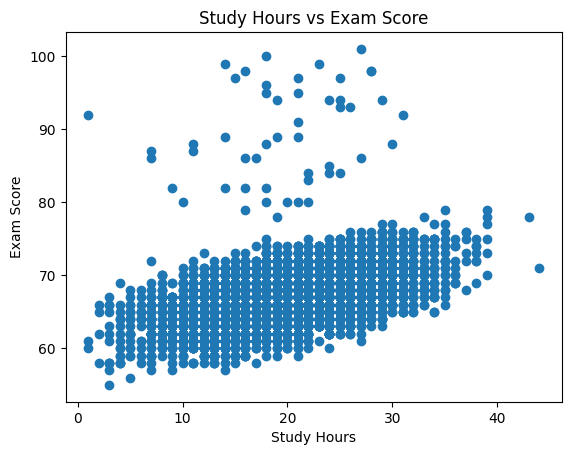

In [10]:
plt.figure()
plt.scatter(df["hours_studied"], df[dependent_var])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()


**Box Plot**

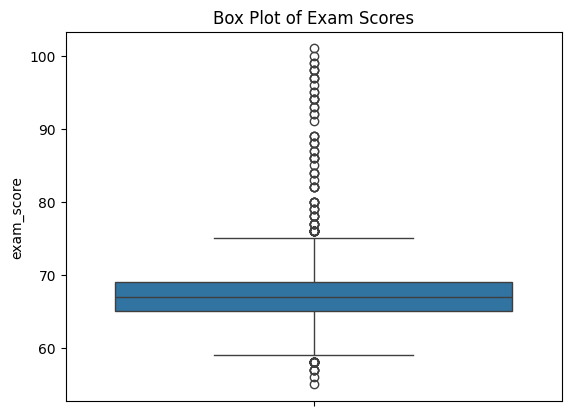

In [11]:
plt.figure()
sns.boxplot(y=df[dependent_var])
plt.title("Box Plot of Exam Scores")
plt.show()


**Histogram**

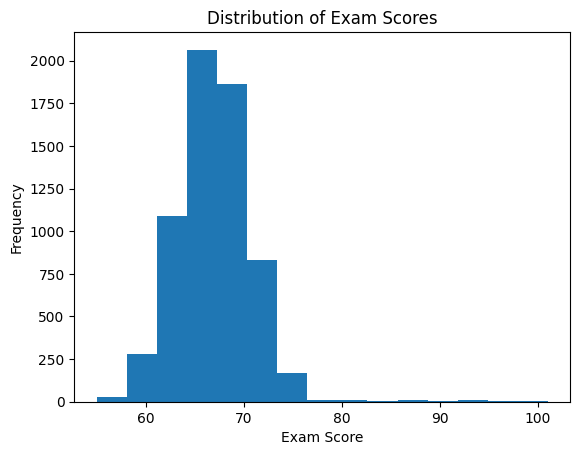

In [12]:
plt.figure()
plt.hist(df[dependent_var], bins=15)
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.title("Distribution of Exam Scores")
plt.show()


**Heat Map (Correlation)**

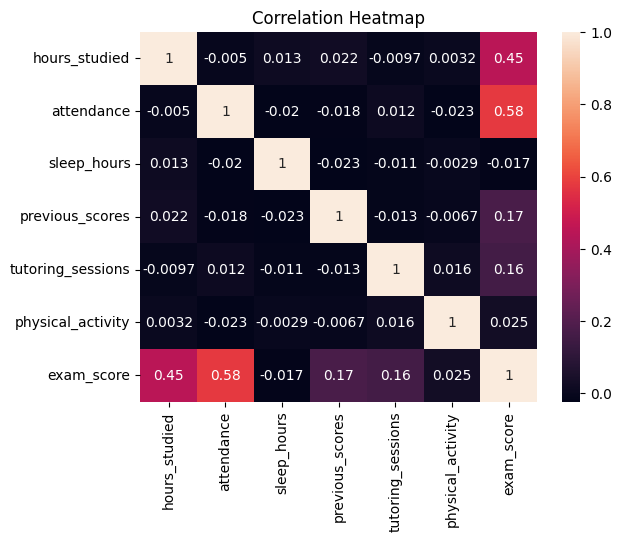

In [13]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


***Hypothesis Testing***

**Pearson Correlation (Numerical)**

In [15]:
corr, p_value = stats.pearsonr(df["hours_studied"], df[dependent_var])
print("Pearson Correlation:", corr)
print("P-value:", p_value)


Pearson Correlation: 0.4451041402651163
P-value: 4.524802143425053e-308


**Chi-Square Test (Categorical Example: Gender)**

In [16]:
contingency = pd.crosstab(df["gender"], df[dependent_var] > df[dependent_var].mean())
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("Chi-Square Value:", chi2)
print("P-value:", p)


Chi-Square Value: 0.001647795875383023
P-value: 0.9676203232474715


***One-Sample T-Test***

In [17]:
population_mean = df[dependent_var].mean()

t_stat, p_val = stats.ttest_1samp(random_sample[dependent_var], population_mean)

print("T-Statistic:", t_stat)
print("P-Value:", p_val)


T-Statistic: 1.396846371090674
P-Value: 0.16453678143709718
